In [1]:
import time
import torchvision
# For image transforms
from torchvision import transforms
# For DATA SET
import torchvision.datasets as datasets
# For Pytorch methods
import torch
import torch.nn as nn
# For Optimizer
import torch.optim as optim
# FOR DATA LOADER
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import torchvision.transforms.functional as F

from denoising_diffusion_pytorch import Unet, GaussianDiffusion

import matplotlib.pyplot as plt

In [ ]:
# Hyperparameters
LEARNING_RATE = 4e-4
BATCH_SIZE = 128  # Batch size
N_EPOCHS = 100
IMAGE_SIZE = 32
TIME_STEPS = 1000
SAMPLING_TIMESTEPS = 250

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# we define a tranform that converts the image to tensor
myTransforms = transforms.Compose([
    transforms.Pad(2),  # Pad the image to 32x32
    transforms.ToTensor()])

# the MNIST dataset is available through torchvision.datasets
print("loading MNIST digits dataset")
dataset = datasets.MNIST(root="dataset/", transform=myTransforms, download=True)
# let's create a dataloader to load the data in batches
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = datasets.MNIST(root='dataset/', train=False, download=False, transform=myTransforms)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

loading MNIST digits dataset


In [4]:
DIM = 32
DIM_MULTS = (1, 2, 4, 8)
model = Unet(
    dim = DIM,
    dim_mults = DIM_MULTS,
    # flash_attn = False,
    channels = 1
).to(device)

diffusion = GaussianDiffusion(
    model,
    image_size = IMAGE_SIZE,
    timesteps = TIME_STEPS,           # number of steps
    sampling_timesteps = SAMPLING_TIMESTEPS    # number of sampling timesteps (using ddim for faster inference [see ddim paper])
).to(device)

optim = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [5]:
# training

train_losses = []
validation_losses = []

for epoch in range(N_EPOCHS):
    epoch_start_time = time.time()
    # implement training loop. You get the loss by calling the diffusion function
    # `loss = diffusion(training_images)`
    model.train()
    train_loss = 0.0

    for batch in loader:
        images = batch[0].to(device)


        optim.zero_grad()
        loss = diffusion(images)
        loss.backward()
        optim.step()
        train_loss += loss.item(
        )

    train_loss /= len(loader)
    train_losses.append(train_loss)

    model.eval()
    validation_loss = 0.0

    with torch.no_grad():
        for batch in test_loader:
            images = batch[0].to(device)
            loss = diffusion(images)
            validation_loss += loss.item()


    validation_loss /= len(test_loader)
    validation_losses.append(validation_loss)

    # STOP THE TIMER
    epoch_end_time = time.time() 
    
    # CALCULATE THE DURATION
    epoch_duration = epoch_end_time - epoch_start_time 
    
    # Convert seconds into minutes and seconds for cleaner formatting
    mins = int(epoch_duration // 60)
    secs = int(epoch_duration % 60)

    # 4. PRINT WITH TIME INCLUDED
    print(
        f"Epoch {epoch+1}/{N_EPOCHS} | "
        f"Time: {mins}m {secs}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {validation_loss:.4f}"
    )


checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optim.state_dict(),
    "train_losses": train_losses,
    "validation_losses": validation_losses,
}

# Generate and save
sampled_images = diffusion.sample(batch_size=16)
sampled_images_28 = F.center_crop(sampled_images, output_size=28)
save_image(sampled_images_28, "mnist_samples_28x28.png", nrow=4)
print("Saved sampled images to mnist_samples_28x28.png!")

/home/freddy/miniforge3/envs/deep-learning/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


Epoch 1/100 | Time: 1m 17s | Train Loss: 0.0855 | Val Loss: 0.0483
Epoch 2/100 | Time: 1m 16s | Train Loss: 0.0407 | Val Loss: 0.0366
Epoch 3/100 | Time: 1m 16s | Train Loss: 0.0360 | Val Loss: 0.0345
Epoch 4/100 | Time: 1m 16s | Train Loss: 0.0341 | Val Loss: 0.0331
Epoch 5/100 | Time: 1m 16s | Train Loss: 0.0325 | Val Loss: 0.0316
Epoch 6/100 | Time: 1m 16s | Train Loss: 0.0319 | Val Loss: 0.0306
Epoch 7/100 | Time: 1m 16s | Train Loss: 0.0310 | Val Loss: 0.0307
Epoch 8/100 | Time: 1m 16s | Train Loss: 0.0307 | Val Loss: 0.0302
Epoch 9/100 | Time: 1m 16s | Train Loss: 0.0302 | Val Loss: 0.0298
Epoch 10/100 | Time: 1m 16s | Train Loss: 0.0297 | Val Loss: 0.0300
Epoch 11/100 | Time: 1m 16s | Train Loss: 0.0298 | Val Loss: 0.0294
Epoch 12/100 | Time: 1m 16s | Train Loss: 0.0297 | Val Loss: 0.0288
Epoch 13/100 | Time: 1m 17s | Train Loss: 0.0294 | Val Loss: 0.0292
Epoch 14/100 | Time: 1m 16s | Train Loss: 0.0291 | Val Loss: 0.0288
Epoch 15/100 | Time: 1m 17s | Train Loss: 0.0289 | Val Lo

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Saved sampled images to mnist_samples_28x28.png!


In [6]:
# Save it to a file
torch.save(checkpoint, "diffusion_mnist_checkpoint.pth")

In [7]:
# Load the checkpoint file
checkpoint = torch.load("diffusion_mnist_checkpoint.pth", map_location=device)

# Restore the states
model.load_state_dict(checkpoint["model_state_dict"])
optim.load_state_dict(checkpoint["optimizer_state_dict"])

# Retrieve your losses
loaded_train_losses = checkpoint["train_losses"]
loaded_validation_losses = checkpoint["validation_losses"]

print("Checkpoint loaded successfully!")

# Put the model in evaluation mode if you are just generating images
model.eval()

Checkpoint loaded successfully!


/tmp/ipykernel_7022/2488128413.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("diffusion_mnist_checkpoint.pth", map_location=device)


Unet(
  (init_conv): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
  (time_mlp): Sequential(
    (0): SinusoidalPosEmb()
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (downs): ModuleList(
    (0): ModuleList(
      (0-1): 2 x ResnetBlock(
        (mlp): Sequential(
          (0): SiLU()
          (1): Linear(in_features=128, out_features=64, bias=True)
        )
        (block1): Block(
          (proj): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (norm): RMSNorm()
          (act): SiLU()
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (block2): Block(
          (proj): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (norm): RMSNorm()
          (act): SiLU()
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (res_conv): Identity()
      )
      (2): Linea

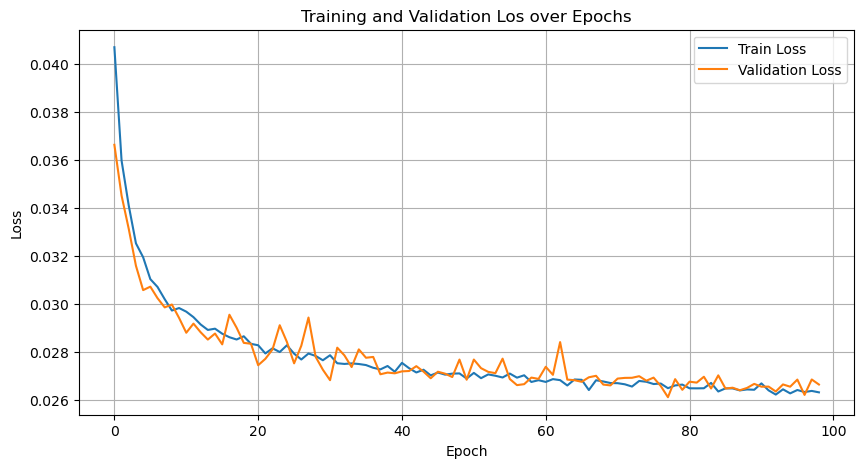

In [8]:
# plot losses

plt.figure(figsize=(10, 5))
plt.plot(loaded_train_losses[1:], label="Train Loss")
plt.plot(loaded_validation_losses[1:], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Los over Epochs")
plt.legend()
plt.grid()
plt.savefig("loss_MNIST.png")
plt.show()

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Saved diffusion process visualization to diffusion_process.png!


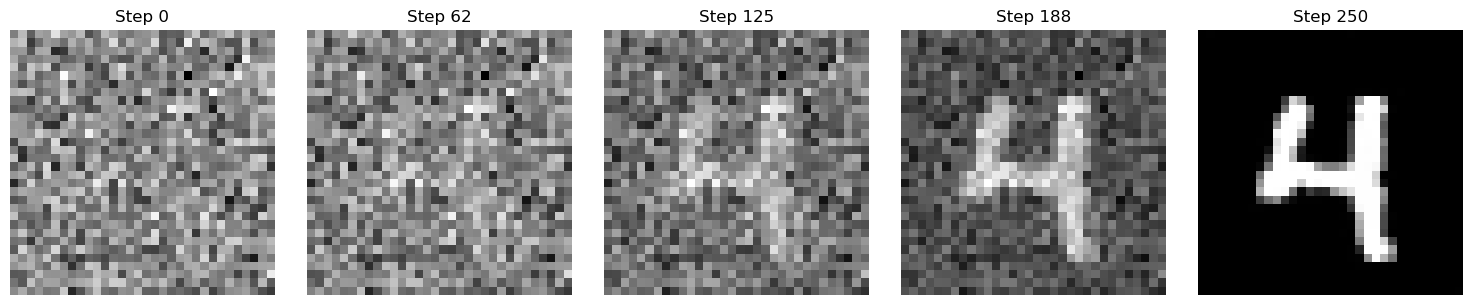

In [9]:
model.eval()

# How many images do you want to trace?
BATCH_SIZE = 1 

with torch.no_grad():
    # Set return_all_timesteps=True
    # Returns shape: (batch_size, sampling_timesteps, channels, height, width)
    all_steps = diffusion.sample(batch_size=BATCH_SIZE, return_all_timesteps=True)

# Squeeze out the batch dimension so we just have (timesteps, channels, height, width)
# and move it to the CPU for matplotlib
sequence = all_steps[0].cpu()

# Pick 5 even intervals to plot 
# (e.g., for 250 steps, we want indices 0, 62, 125, 187, 249)
total_steps = sequence.shape[0]
step_indices = [
    0, 
    int(total_steps * 0.25), 
    int(total_steps * 0.50), 
    int(total_steps * 0.75), 
    total_steps - 1
]

# Set up the plot
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, step_idx in enumerate(step_indices):
    # Grab the image at this specific timestep
    img = sequence[step_idx]

    
    # Reshape from (1, H, W) to (H, W) for grayscale plotting
    img = img.squeeze(0)
    
    # Plot it
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Step {step_idx}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("diffusion_process.png")
print("Saved diffusion process visualization to diffusion_process.png!")

In [10]:
# calculate FID score
from torchmetrics.image.fid import FrechetInceptionDistance



# ---------------------------------------------------------
# SETUP
# ---------------------------------------------------------
# feature=64 uses a smaller pool of Inception features for faster calculation. 
# (Note: For official research papers, you would use feature=2048).
fid = FrechetInceptionDistance(feature=64).to(device)

# We will test on 1,000 images. 
# (Standard is 10k to 50k, but 1,000 gives a great estimate without taking an hour).
NUM_IMAGES = 1000
BATCH_SIZE = 100  # Process in chunks to save VRAM

# ---------------------------------------------------------
# STEP 1: Process REAL Images
# ---------------------------------------------------------
print("Processing REAL images...")
# Load the test set using your padded 32x32 transforms
test_dataset = datasets.MNIST(root='dataset/', train=False, download=True, transform=myTransforms)
real_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

real_images_processed = 0
for batch in real_loader:
    real_images = batch[0].to(device) # Shape: [100, 1, 32, 32]
    
    # Quirk Fix 1: Repeat the grayscale channel 3 times to mimic RGB
    real_images = real_images.repeat(1, 3, 1, 1) # New shape: [100, 3, 32, 32]
    
    # Quirk Fix 2: Convert from float [0, 1] to uint8 [0, 255]
    real_images = (real_images * 255).to(torch.uint8)
    
    # Add to the FID real distribution
    fid.update(real_images, real=True)
    
    real_images_processed += real_images.shape[0]
    if real_images_processed >= NUM_IMAGES:
        break

# ---------------------------------------------------------
# STEP 2: Generate and Process FAKE Images
# ---------------------------------------------------------
print(f"Generating {NUM_IMAGES} FAKE images... (this will take a few minutes)")
diffusion.eval()

with torch.no_grad():
    # Loop 10 times (10 * 100 = 1000 images)
    for _ in range(NUM_IMAGES // BATCH_SIZE):
        # Generate fake images. These output in your standard [0.0, 1.0] range
        fake_images = diffusion.sample(batch_size=BATCH_SIZE)
        
        # Apply the exact same Quirk Fixes to the fake images
        fake_images = fake_images.repeat(1, 3, 1, 1)
        fake_images = (fake_images * 255).to(torch.uint8)
        
        # Add to the FID fake distribution
        fid.update(fake_images, real=False)

# ---------------------------------------------------------
# STEP 3: Compute the Score
# ---------------------------------------------------------
print("Calculating statistical distance...")
fid_score = fid.compute()
print(f"=============================")
print(f"FINAL FID SCORE: {fid_score.item():.4f}")
print(f"=============================")


Processing REAL images...
Generating 1000 FAKE images... (this will take a few minutes)


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

...

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Calculating statistical distance...
FINAL FID SCORE: 0.0008


In [11]:
sampled_images = diffusion.sample(batch_size=64)
sampled_images_28 = F.center_crop(sampled_images, output_size=28)
save_image(sampled_images_28, "mnist_samples_big.png", nrow=8)

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]